## 1: Missing Values for US income data

### Question 1-1

Today, we will be using the ACS data we used during out first `pandas` exercise to examine the US income distribution, and how it varies by race. Note that because the US income distribution has a very small number of people with *extremely* high incomes, and the ACS is just a sample of Americans, the far right tail of the distribution will not be very well estimated. However, this data should suffice for helping to understand wealth inequality in the United States. 

To begin, load the ACS Data we used in our first pandas exercise. That data can be found on Moodle. We'll be working with `US_ACS_2017_10pct_sample.dta`. 

In [78]:
import pandas as pd
acs = pd.read_stata("US_ACS_2017_10pct_sample.dta")
acs.head()

,year,datanum,serial,cbserial,numprec,subsamp,hhwt,hhtype,cluster,adjust,...,migcounty1,migmet131,vetdisab,diffrem,diffphys,diffmob,diffcare,diffsens,diffeye,diffhear
0,2017,1,177686,2.017001e+12,9,64,55,"female householder, no husband present",2.017002e+12,1.011189,...,0,not in identifiable area,n/a,n/a,n/a,n/a,n/a,no vision or hearing difficulty,no,no
1,2017,1,1200045,2.017001e+12,6,79,25,"male householder, no wife present",2.017012e+12,1.011189,...,0,not in identifiable area,n/a,no cognitive difficulty,no ambulatory difficulty,no independent living difficulty,no,no vision or hearing difficulty,no,no
2,2017,1,70831,2.017000e+12,1 person record,36,57,"male householder, living alone",2.017001e+12,1.011189,...,0,not in identifiable area,n/a,has cognitive difficulty,no ambulatory difficulty,no independent living difficulty,no,no vision or hearing difficulty,no,no
3,2017,1,557128,2.017001e+12,2,10,98,married-couple family household,2.017006e+12,1.011189,...,0,not in identifiable area,n/a,no cognitive difficulty,no ambulatory difficulty,no independent living difficulty,no,no vision or hearing difficulty,no,no
4,2017,1,614890,2.017001e+12,4,96,54,married-couple family household,2.017006e+12,1.011189,...,0,not in identifiable area,n/a,n/a,n/a,n/a,n/a,no vision or hearing difficulty,no,no


### Question 1-2

Let's begin by calculating the mean US incomes from this data (recall that income is stored in the `inctot` variable). Store the answer in `results` under the key `"ex2_avg_income"`.

In [79]:
# Calculate average income
avg_income = acs["inctot"].mean()

# Stores the results in the dictionary
results = {}
results["ex2_avg_income"] = avg_income

# print results
print("Average US income:", avg_income)

Average US income: 1723646.2703978634


### Question 1-3

Hmmm... That doesn't look right. The average American is definitely not earning that much a year! Let's look at the values of `inctot` using `value_counts()`. Do you see a problem?

Now use `value_counts()` with the argument `normalize=True` to see proportions of the sample that report each value instead of the count of people in each category. What percentage of our sample has an income of 9,999,999? Store that proportion (between 0 and 1) as `"ex3_share_making_9999999"`. What percentage has an income of 0? Store that proportion as `"ex3_share_making_zero"`.

(Recall `.value_counts()` returns a Series, so you can pull values out with our usual pandas tools.)

In [80]:
# check income distribution
acs["inctot"].value_counts().head(10)

# Calculate the proportion of each income value in the sample
income_share = acs["inctot"].value_counts(normalize=True)

# Proportion of specified income levels taken out
share_9999999 = income_share.get(9999999, 0)
share_zero = income_share.get(0, 0)

# Save results
results ["ex3_share_making_9999999"] = share_9999999
results["ex3_share_making_zero"] = share_zero

print("Proportion making 9,999,999:", share_9999999)
print("Proportion making 0:", share_zero)
results


Proportion making 9,999,999: 0.1689665333350052
Proportion making 0: 0.10557547867738336


{'ex2_avg_income': np.float64(1723646.2703978634),
 'ex3_share_making_9999999': np.float64(0.1689665333350052),
 'ex3_share_making_zero': np.float64(0.10557547867738336)}

### Question 1-4

As we discussed before, the ACS uses a value of 9999999 to denote that income information is not available for someone. The problem with using this kind of "sentinel value" is that pandas doesn't understand that this is supposed to denote missing data, and so when it averages the variable, it doesn't know to ignore 9999999. 

To help out `pandas`, use the `replace` command to replace all values of 9999999 with `np.nan`. 

In [81]:
import numpy as np
# Replace 9999999 with np.nan.
acs["inctot"] = acs["inctot"].replace(9999999, np.nan)

print(acs["inctot"].value_counts(dropna=False).head(10))

inctot
NaN        53901
0.0        33679
30000.0     4778
50000.0     4414
40000.0     4413
20000.0     4067
60000.0     3618
12000.0     3545
25000.0     3366
35000.0     2928
Name: count, dtype: int64


### Question 1-5

Now that we've properly labeled our missing data as `np.nan`, let's calculate the average US income once more. Store the answer in `results` under the key `"ex5_avg_income"`.

In [82]:
# Recalculate the average US income after replacing 9999999 with NaN
avg_income_cleaned = acs["inctot"].mean()
results["ex5_avg_income"] = avg_income_cleaned
print("Average US income (cleaned):", avg_income_cleaned)

Average US income (cleaned): 40890.177564946454


### Question 1-6

OK, now we've been able to get a reasonable average income number. As we can see, a major advantage of using `np.nan` is that `pandas` knows that `np.nan` observations should just be ignored when we are calculating means. 

But it's not enough to just get rid of the people who had `inctot` values of 9999999. We also need to know why those values were missing. Suppose, for example, that the value of 9999999 was used for anyone who made more than 100,000 dollars: if we just dropped those people, then our estimate of average income wouldn't mean much, would it?

So let's make sure we understand *why* data is missing for some people. If you recall from our last exercise, it seemed to be the case that most of the people who had incomes of 9999999 were children. Let's make sure that's true by looking at the distribution of the variable `age` for people for whom `inctot` is missing (i.e. subset the data to people with `inctot` missing, then look at the values of `age` with `value_counts()`).

Then do the opposite: look at the distribution of the `age` variable for people who whom `inctot` is *not* missing. 

Can you determine when 9999999 was being used? Is it ok we're excluding those people from our analysis?

Note: In this data, Python doesn't understand `age` is a number; it thinks it is a string because the original data has categories like "90 (90+ in 1980 and 1990)" and "less than 1 year old". So you can't just use `min()` or `max()`. We'll discuss converting string variables into numbers in a future class.

In [83]:
# View the age distribution of people with missing income (NaN)
missing_income = acs[acs["inctot"].isna()]
print("People with missing income (NaN): age distribution\n")
print(missing_income["age"].value_counts().head(20))

# View the age distribution of people with no missing income
non_missing_income = acs[acs["inctot"].notna()]
print("\nPeople with reported income: age distribution\n")
print(non_missing_income["age"].value_counts().head(20))

People with missing income (NaN): age distribution

age
10                      3997
9                       3977
14                      3847
12                      3845
13                      3800
11                      3791
8                       3648
7                       3527
6                       3524
5                       3512
2                       3405
1                       3340
4                       3318
3                       3220
less than 1 year old    3150
15                         0
16                         0
17                         0
18                         0
19                         0
Name: count, dtype: int64

People with reported income: age distribution

age
60    4950
54    4821
56    4776
59    4776
58    4734
57    4720
55    4693
61    4644
62    4614
53    4600
18    4496
63    4488
52    4418
65    4362
19    4342
64    4287
50    4272
47    4256
16    4106
66    4106
Name: count, dtype: int64


The people with missing income (inctot = NaN) are almost entirely children under 15 years old. including many labeled as "less than 1 year old".
In contrast, people with reported income are mostly adults between 18 and 65 years old.
Therefore, the missing income values (originally 9999999) were used for individuals not in the labor force, mainly children, and it is reasonable to exclude them from our income analysis.


### Question 1-7

Great, so now we know why those people had missing data, and we're ok with excluding them. 

But as we previously noted, there are also a lot of observations of zero income in our data, and it's not clear that we want everyone with a zero-income *should* be included in this average, since those may be people who are retired, or in school. 

Let's limit our attention to people who are currently working by subsetting to only employed respondents. We can do this using `empstat`. Remember you can use `value_counts()` to see what values of `empstat` are in the data!

In [84]:
# View Employment Status Distribution
print(acs["empstat"].value_counts())

# Retain only those with empstat == "employed"
employed = acs[acs["empstat"] == "employed"]

# Check the number of samples after screening
print("Number of employed respondents:", len(employed))

# Check Income Distribution
print("\nIncome distribution among employed respondents:")
print(employed["inctot"].describe())

empstat
employed              148758
not in labor force    104676
n/a                    57843
unemployed              7727
Name: count, dtype: int64
Number of employed respondents: 148758

Income distribution among employed respondents:
count    1.487580e+05
mean     5.785472e+04
std      7.096565e+04
min     -9.000000e+03
25%      2.100000e+04
50%      4.000000e+04
75%      7.000000e+04
max      1.563000e+06
Name: inctot, dtype: float64


### Question 1-8

Now let's estimate the racial income gap in the United States. What is the average salary for employed Black Americans, and what is the average salary for employed White Americans? In percentage terms, how much more does the average White American make than the average Black American?

**Note:** these values are not quite accurate estimates. As we'll discuss in later lessons, to get completely accurate estimates from the ACS we have to take into account how people were selected to be interviewed. But you get pretty good estimates in most cases even without weights—your estimate of the racial wage gap without weights is within 5\% of the corrected value. 

**Note:** This is actually an underestimate of the wage gap. The US Census treats Hispanic respondents as a sub-category of "White." While all ethnic distinctions are socially constructed, and so on some level these distinctions are all deeply problematic, this coding is inconsistent with what most Americans think of when they hear the term "White," a term *most* Americans think of as a category that is mutually exclusive of being Hispanic or Latino (categories which are also usually conflated in American popular discussion). With that in mind, most researchers working with US Census data split "White" into "White, Hispanic" and "White, Non-Hispanic" using `race` *and* `hispan`. But for the moment, just identify "White" respondents using the value in `race`.

Store your results in `results` under the keys `"ex8_avg_income_black"`, `"ex8_avg_income_white"`, and the percentage difference as `ex8_racial_difference`. Please note the wording above when calculating the percentage difference to ensure you get the reference category correct, and interpret your result as well.

In [85]:
# View race Categories
print(employed["race"].value_counts())

# Calculation of average income
avg_white = employed.loc[employed["race"] == "white", "inctot"].mean()
avg_black = employed.loc[employed["race"] == "black/african american/negro", "inctot"].mean()

# Calculation of the percentage gap
racial_gap = ((avg_white - avg_black) / avg_black) * 100

# Save results
results["ex8_avg_income_white"] = avg_white
results["ex8_avg_income_black"] = avg_black
results["ex8_racial_difference"] = racial_gap

# print results
print(f"Average income (White): {avg_white:.2f}")
print(f"Average income (Black): {avg_black:.2f}")
print(f"White Americans earn {racial_gap:.2f}% more than Black Americans on average.")
results

race
white                               116017
black/african american/negro         13175
other asian or pacific islander       6424
other race, nec                       5755
two major races                       3135
chinese                               2149
american indian or alaska native      1290
three or more major races              426
japanese                               387
Name: count, dtype: int64
Average income (White): 60473.15
Average income (Black): 41747.95
White Americans earn 44.85% more than Black Americans on average.


{'ex2_avg_income': np.float64(1723646.2703978634),
 'ex3_share_making_9999999': np.float64(0.1689665333350052),
 'ex3_share_making_zero': np.float64(0.10557547867738336),
 'ex5_avg_income': np.float64(40890.177564946454),
 'ex8_avg_income_white': np.float64(60473.15372747098),
 'ex8_avg_income_black': np.float64(41747.949905123336),
 'ex8_racial_difference': np.float64(44.85299006275197)}

### Question 1-9


As noted above, these estimates are not actually *quite* correct because we aren't taking into account the fact that when the US Census decided who to survey, not all Americans had the same likelihood of being asked. The US American Community Survey is an example of a *weighted* survey (essentially, people from smaller subpopulations have a higher likelihood of being included to ensure enough individuals in the final survey to constitute a representative sample that can be used statistically). 

To calculate a weighted average that takes into account these survey weights (in other words, a more accurate estimate of US incomes), you need to use the following formula:

$$weighted\_mean\_of\_x = \frac{\sum_i x_i * weight_i}{\sum_i weight_i}$$

(As you can see, when $weight_i$ is constant for all observations, this just simplifies to our normal formula for mean values. It is only when weights vary across individuals that weights must be explicitly addressed).

In this data, weights are stored in the variable `perwt`, which is the number of people for which each observation is a stand-in (the inverse of that observation's sampling probability). 

Using the formula, re-calculate the *weighted* average income for both populations and store them as `ex9_avg_income_white` and `ex9_avg_income_black`.


In [86]:
# Calculate the weighted average function
def weighted_mean (data, value_col, weight_col):
    return (data[value_col] * data[weight_col]).sum() / data[weight_col].sum()

# Calculate weighted average income separately
white_data = employed[employed["race"] == "white"]
black_data = employed[employed["race"] == "black/african american/negro"]

avg_white_weighted = weighted_mean(white_data, "inctot", "perwt")
avg_black_weighted = weighted_mean(black_data, "inctot", "perwt")

# Save results
results["ex9_avg_income_white"] = avg_white_weighted
results["ex9_avg_income_black"] = avg_black_weighted

print(f"Weighted avg income (White): {avg_white_weighted:.2f}")
print(f"Weighted avg income (Black): {avg_black_weighted:.2f}")

Weighted avg income (White): 58361.48
Weighted avg income (Black): 40430.95


### Question 1-10

Now calculate the weighted average income gap between *non-Hispanic* White Americans and Black Americans. What percentage more do employed White non-Hispanic Americans earn than employed Black Americans? Store as `"ex10_wage_gap"`.

In [87]:
# Selection of non-Hispanic whites
white_nonhisp = employed[
    (employed["race"] == "white") &
    (employed["hispand"] == "not hispanic")
]

# Choosing Blacks
black = employed[employed["race"] == "black/african american/negro"]

# Weighted average function
def weighted_mean(data, value_col, weight_col):
    return (data[value_col] * data[weight_col]).sum() / data[weight_col].sum()

# Calculate weighted average incomes
avg_white_nonhisp = weighted_mean(white_nonhisp, "inctot", "perwt")
avg_black = weighted_mean(black, "inctot", "perwt")

# Percentage wage gap
wage_gap = ((avg_white_nonhisp - avg_black) / avg_black) * 100

# Save result
results["ex10_wage_gap"] = wage_gap

print(f"Weighted avg income (White, non-Hispanic): {avg_white_nonhisp:.2f}")
print(f"Weighted avg income (Black): {avg_black:.2f}")
print(f"Non-Hispanic Whites earn {wage_gap:.2f}% more than Black Americans.")

Weighted avg income (White, non-Hispanic): 61669.29
Weighted avg income (Black): 40430.95
Non-Hispanic Whites earn 52.53% more than Black Americans.


### Question 1-11

Is that greater or less than the difference you found in Exercise 8? Why do you think that's the case?

The income gap in Exercise 10 (about 52.5%) is greater than the gap in Exercise 8 (about 44.9%).
This is because in Exercise 10 we excluded Hispanic Whites from the White category.
Hispanic Whites tend to have lower average incomes than non-Hispanic Whites,
so removing them raises the overall White average income while leaving the Black average unchanged.
As a result, the measured income gap between Whites and Blacks becomes larger.

## Question 2 Wealth and Democracy: Plotting

**Remember that we always want to make good plots, we will try to make perfect plots.**

In these questions, we will be working with country-year level data from the World Development Indicators (published by the World Bank) to understand the relationship between wealth and democratic institutions.

This WDI data includes both countries' GDP per capita (a measure of wealth) and [Polity IV scores](https://en.wikipedia.org/wiki/Polity_data_series) (a measure of how democratic a country is -- countries with higher scores are liberal democracies countries with low scores are autocratic). 

Note by "liberal," we mean [reflecting the values of traditional liberalism](https://en.wikipedia.org/wiki/Liberalism) with a small-`l`, not Liberal in the sense of being associated with the US Democratic party.

In [88]:
# Write your code here, add another cell if you need to write markdown formate.

### Question 2-1


Let's begin analyzing this data by estimating a simple linear model ("ordinary least squares") of the relationship between democracy scores (`polityIV`) and GDP per capita (`gdppcap08`). Polity Scores are the outcome we care about, so make it the dependent variable in your model. We will do so using the `statsmodel` package, which we'll discuss in detail later is this course. For the moment, just use this code:

```python
import statsmodels.formula.api as smf
results = smf.ols('polityIV ~ gdppcap08',
                   data=wdi).fit()
print(results.summary())
```

In [89]:
import pandas as pd

wdi = pd.read_csv("wdi_data.csv")
wdi.head()

import  statsmodels.formula.api as smf
results = smf.ols('polityIV ~ gdppcap08', data = wdi).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               polityIV   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     6.981
Date:                Tue, 07 Oct 2025   Prob (F-statistic):            0.00915
Time:                        16:38:01   Log-Likelihood:                -475.14
No. Observations:                 145   AIC:                             954.3
Df Residuals:                     143   BIC:                             960.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.1354      0.721     16.841      0.0

### Question 2-2

Based on the results of this analysis, what would you conclude about the relationship between `gdppcap08` and `polityIV`? 

Write down your conclusions. 

There is a positive and statistically significant relationship between GDP per capita (gdppcap08)
and democracy scores (polityIV).
Countries with higher income levels tend to have higher democracy scores.
This suggests that economic development is associated with more democratic institutions,
although GDP alone does not explain all differences in democracy.

### Question 2-3

Now let's plot the relationship you just estimated statistically. First, use `seaborn.objects` to create a scatter plot of `polityIV` and `gdppcap08`. Include a title and label your axes (with formatted words, not variable names).

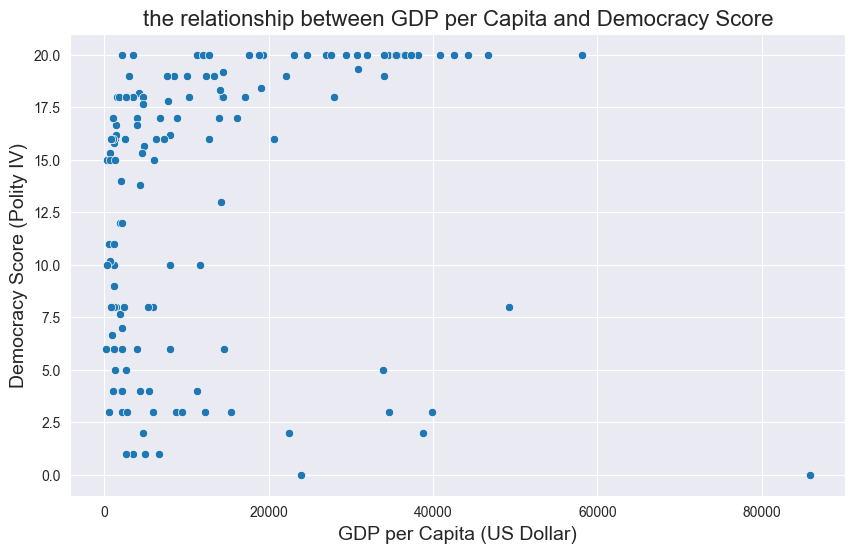

In [90]:
# Write your code here, add another cell if you need to write markdown formate.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#load the csv data
wdi = pd.read_csv('wdi_data.csv')

#create the plot
plt.figure(figsize=(10, 6))
scatter_plot = sns.scatterplot(x='gdppcap08', y='polityIV', data=wdi)
plt.title('the relationship between GDP per Capita and Democracy Score', fontsize=16)
plt.xlabel('GDP per Capita (US Dollar)', fontsize=14)
plt.ylabel('Democracy Score (Polity IV)', fontsize=14)
plt.show()

### Question 2-4

Now overlay a linear regression (*not* a higher order polynomial, just linear) fit to the scatter plot.

Note: linear regression is *not* symmetric — regressing Polity IV on GDP per Capita does not give the same result as regressing GDP per Capita on Polity IV. That's because linear regression is designed to minimize the sum of squared errors between predicted values of the y-variable and the true values of the y-variable, so the y-variable is, in a sense, privileged. 

Given that, for consistency be sure you make your plot reflect the regression you ran above.

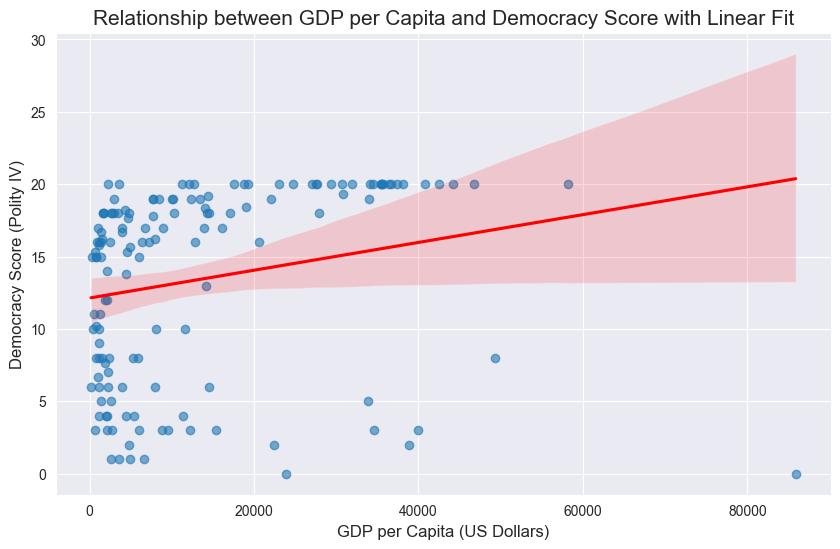

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.regplot(
    x="gdppcap08",
    y="polityIV",
    data=wdi,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)
plt.title("Relationship between GDP per Capita and Democracy Score with Linear Fit", fontsize=15)
plt.xlabel("GDP per Capita (US Dollars)", fontsize=12)
plt.ylabel("Democracy Score (Polity IV)", fontsize=12)
plt.show()

### Question 2-5

Does it seem like the linear model you estimated fits the data well?

From the plot, we can see that the linear model does not fit the data very well.
The dispersion of the data points is quite high, and many observations deviate substantially from the regression line.
This suggests that the relationship between GDP per capita and democracy is weak and may not be strictly linear.

### Question 2-6

Linear models impose a very strict functional form on the model they use: they try to draw a straight line through the data, no matter what. 

Can you think of a (mathematical) transformation for your data that would make the data a little more sane?

Apply the transformation.

1. log transformation: for example the range of the GDP is wide, applying for a
log transformation could compress the data scale and make a fit linear
regression realtion new variable = log(original +1)

2. sqaure root transformation: it could help stabilize the variance new variable
= sqrt(original)

3. inverse transformation: it can determine the best way to transform data by
trying different values of λ to make the data as normal as possible 1/original

### Question 2-7

Once you've applied that transformation, let's re-fit our model. 

Has you sense of the relationship changed at all?

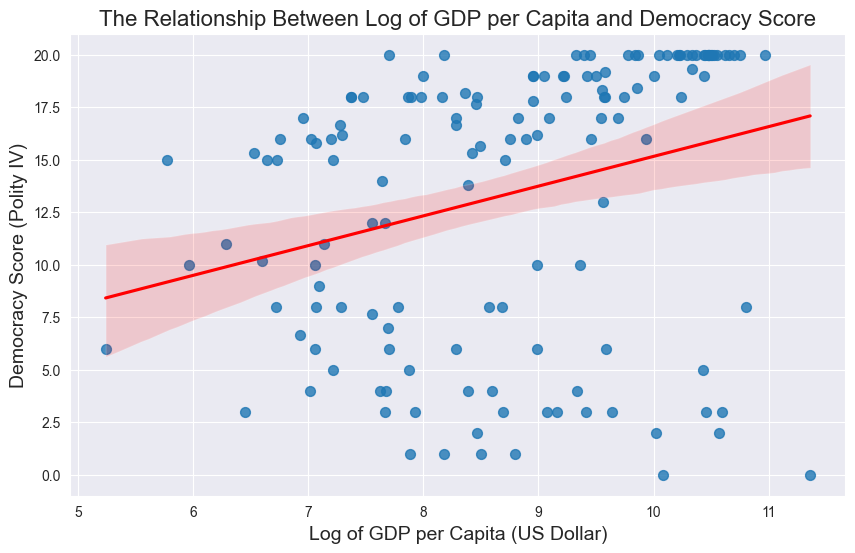

In [92]:
# choose to use the log transformation with current model
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

wdi = pd.read_csv('wdi_data.csv')
wdi['gdppcap08_log'] = np.log1p(wdi['gdppcap08'])

plt.figure(figsize=(10, 6))

sns.regplot(x='gdppcap08_log', y='polityIV', data=wdi,
            scatter_kws={'s': 50}, line_kws={'color': 'red'})

plt.title('The Relationship Between Log of GDP per Capita and Democracy Score', fontsize=16)
plt.xlabel('Log of GDP per Capita (US Dollar)', fontsize=14)
plt.ylabel('Democracy Score (Polity IV)', fontsize=14)

plt.show()

The reason for choosing the log transformation is the data for the GDP is
increasing. The log transformation is useful when the data is described as the
inceasing data. Applying the log transformation to the GDP data per capita might
linearize this relationship. Making it is more fit with the linear regression

### Question 2-8

When unsure of the most appropriate functional form for a model, it can be useful to fit a *non-parametric* model — one that does not impose a functional form as strictly. 

Fit a lowess regression with confidence intervals using the `seaborn_objects_recipes` package.

`frac` is a keyword that manages how much lowess will smooth it's estimates across the data — higher values will be more smoothed, lower values with fit the data much tighter. Play with the values till you find something you think feels informative.

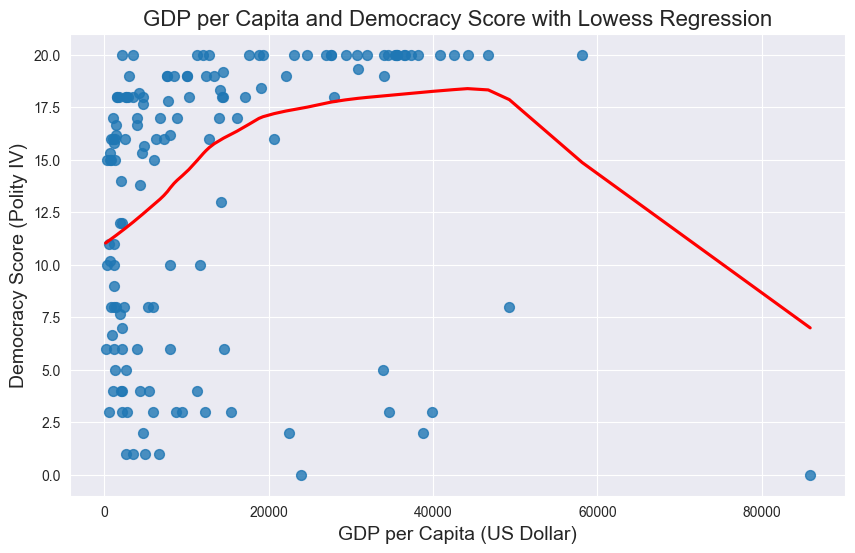

In [93]:
plt.figure(figsize=(10, 6))
sns.regplot(x='gdppcap08', y='polityIV', data=wdi, lowess=True, scatter_kws={'s': 50}, line_kws={'color': 'red'}, ci=None)

plt.title('GDP per Capita and Democracy Score with Lowess Regression', fontsize=16)
plt.xlabel('GDP per Capita (US Dollar)', fontsize=14)
plt.ylabel('Democracy Score (Polity IV)', fontsize=14)
plt.show()

### Question 2-9

This does seem to fit the data better, but there seem to be quite a few outliers in the bottom right. Who is that? Add text labels to the points on your graph with country names. 

Make sure the size of your text labels leaves them legible. There are enough points you won't be able to perfectly see all labels, but do your best.

You can also add `so.Jitter()` to "jitter" the location of labels (move them randomly so when several points share an exact coordinate, they'll be shifted a little).

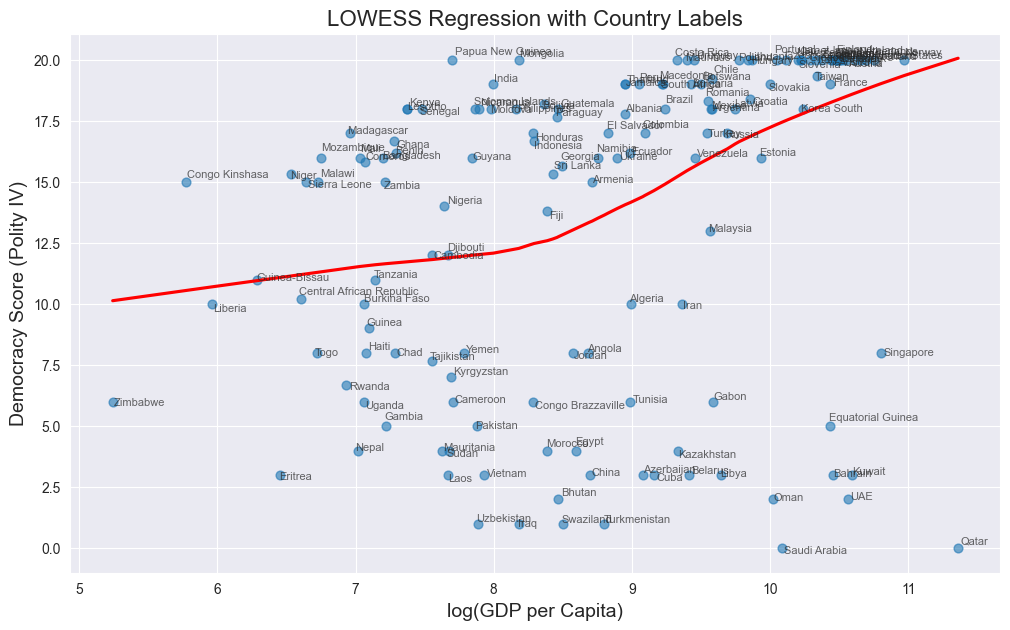

In [94]:
# Creating a log transform column
wdi["log_gdppcap08"] = np.log(wdi["gdppcap08"] + 1)

# Plotting the LOWESS regression scatterplot
plt.figure(figsize=(12, 7))
sns.regplot(
    x="log_gdppcap08", y="polityIV", data=wdi,
    lowess=True, scatter_kws={'alpha': 0.6, 's': 40}, line_kws={'color': 'red'}
)

# Add country name labels to each point
for i in range(len(wdi)):
    plt.text(
        wdi["log_gdppcap08"][i] + np.random.uniform(-0.02, 0.02),
        wdi["polityIV"][i] + np.random.uniform(-0.3, 0.3),
        wdi["country"][i],
        fontsize=8, alpha=0.7
    )

plt.title("LOWESS Regression with Country Labels", fontsize=16)
plt.xlabel("log(GDP per Capita)", fontsize=14)
plt.ylabel("Democracy Score (Polity IV)", fontsize=14)
plt.show()


### Question 2-10

Interesting. It seems that there's are a lot of rich, undemocratic countries that all have something in common: they're oil-rich, small, Middle Eastern countries.

Let's see what happens if we exclude the ten countries with the highest per-capita oil production from our data: Qatar, Kuwait, Equatorial Guinea, United Arab Emirates, Norway, Saudi Arabia, Libya, Oman, Gabon, and Angola. (Note this was in 2007, and excludes very small countries!) 

What does the relationship between Polity and GDP per capita look like for **non**-natural resource producers?

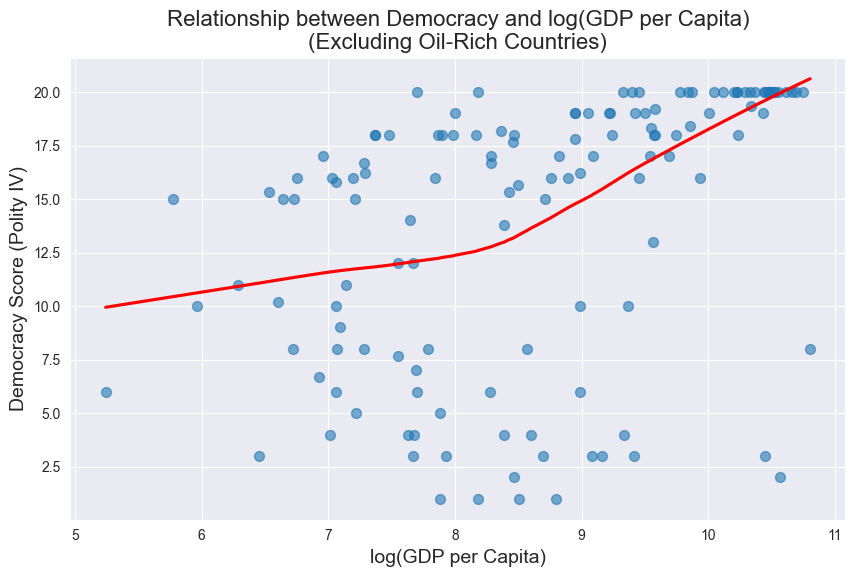

Number of remaining countries: 136


In [95]:
# 10 oil countries to exclude
oil_countries = [
    "Qatar", "Kuwait", "Equatorial Guinea", "United Arab Emirates",
    "Norway", "Saudi Arabia", "Libya", "Oman", "Gabon", "Angola"
]

# Excluding these countries
wdi_non_oil = wdi[~wdi["country"].isin(oil_countries)]

# plotting the LOWESS regression
plt.figure(figsize=(10, 6))
sns.regplot(
    x="log_gdppcap08", y="polityIV", data=wdi_non_oil,
    lowess=True, scatter_kws={'alpha':0.6, 's':50}, line_kws={'color':'red'}
)

plt.title("Relationship between Democracy and log(GDP per Capita)\n(Excluding Oil-Rich Countries)", fontsize=16)
plt.xlabel("log(GDP per Capita)", fontsize=14)
plt.ylabel("Democracy Score (Polity IV)", fontsize=14)
plt.show()

# Checking the number of remaining countries
print(f"Number of remaining countries: {len(wdi_non_oil)}")

### Question 2-11

Let's make sure that you accurately identified all 10 of the oil producers. Write a line of code to count up how many big producers you have identified. If you do not get 10, can you figure out what you did wrong?

In [96]:
big_oil_producers = ['Qatar', 'Kuwait', 'Equatorial Guinea', 'UAE', 'Norway',
                     'Saudi Arabia', 'Libya', 'Oman', 'Gabon', 'Angola']

count_big_producers = wdi[wdi['country'].isin(big_oil_producers)].shape[0]

print(f"Number of big oil producers identified: {count_big_producers}")

Number of big oil producers identified: 10


### Question 2-12

How does the relationship between GDP per capita and Polity look for the oil producers we dropped above?

(Note you can't add a confidence interval given there are only 10 observations here, so drop the CIs)

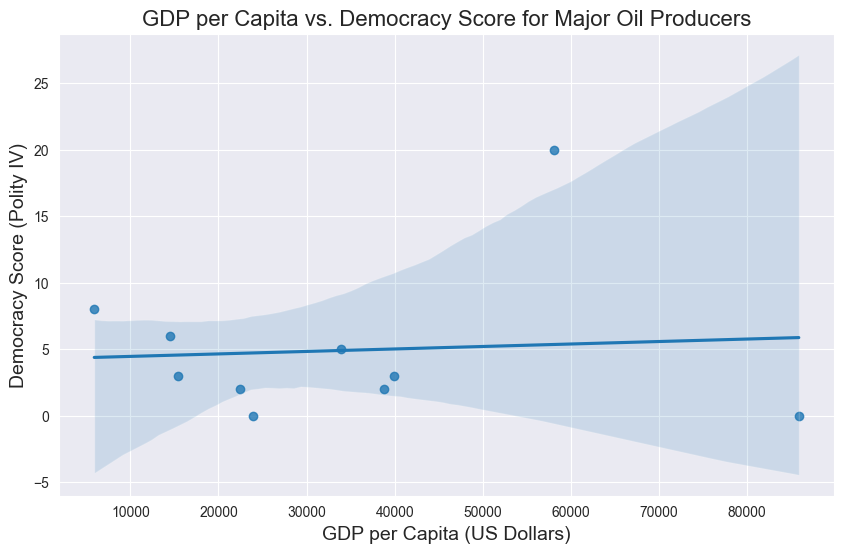

In [97]:
oil_producers_data = wdi[wdi['country'].isin(big_oil_producers)]
plt.figure(figsize=(10, 6))
sns.regplot(x='gdppcap08', y='polityIV', data=oil_producers_data, scatter=True, fit_reg=True)
plt.title('GDP per Capita vs. Democracy Score for Major Oil Producers', fontsize=16)
plt.xlabel('GDP per Capita (US Dollars)', fontsize=14)
plt.ylabel('Democracy Score (Polity IV)', fontsize=14)
plt.show()

### Question 2-13

Look back to your answer for Exercise 2. Do you still believe the result of your linear model? What did you learn from plotting. 

limited data points: the graph is based on the major 10 countries to draw. The
sample size is small. This will reduce the conclusion based on the data The linear
relationship in the plot for oil producers appears flat Other factors: when the
average GDP are the similar, they may have other factors to effect the
result(such as history, political etc) R^2 value is low, the original R^2 value is
0.047. This may cuase the prediction model is weak coefficient size: the
coefficient size is small, that means democracy score only increase a bit when
the GDP increase

What did you learn from plotting
1. The plot for oil producers underscores the importance of contextual factors
2. The linear model may not be appropriate for all subsets of data, sometimes
the linear model will only show the limit information

### Question 2-14

Finally, let's make a plot that color codes countries by whether they are big oil producers. Include separate linear regression fits for both groups.

<Figure size 1000x600 with 0 Axes>

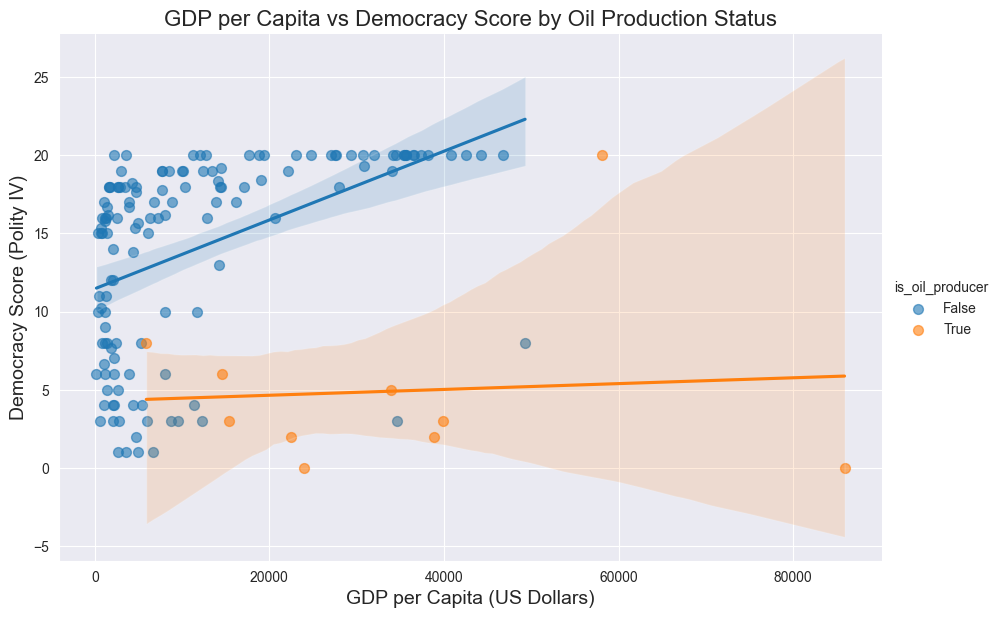

In [98]:
# Create a new column to mark whether it is an oil producing country or not
wdi['is_oil_producer'] = wdi['country'].isin(big_oil_producers)


plt.figure(figsize=(10, 6))
sns.lmplot(
    data=wdi,
    x='gdppcap08',
    y='polityIV',
    hue='is_oil_producer',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.6, 's': 50}
)

plt.title('GDP per Capita vs Democracy Score by Oil Production Status', fontsize=16)
plt.xlabel('GDP per Capita (US Dollars)', fontsize=14)
plt.ylabel('Democracy Score (Polity IV)', fontsize=14)
plt.show()

## Take-aways

One of our main jobs as data scientists is to *summarize* data. In fact, its such an obvious part of our jobs we often don't think about it very much. In reality, however, this is one of the most difficult things we do. 

Summarization means taking rich, complex data and trying to tell readers about what is going on in that data using simple statistics. In the process of summarization, therefore, we must necessarily throw away much of the richness of the original data. When done well, this simplification makes data easier to understand, but only if we throw away the *right* data. You can *always* calulate the average value of a variable, or fit a linear model, but whether doing so generates a summary statistic that properly represents the essence of the data being studied depends on the data itself. 

Plotting is one fo the best tools we have as data scientists for evaluating whether we are throwing away the *right* data. As we learned from Part 1 of this exercise, just looking at means and standard deviations can mask tremendous variation. Each of our example datasets looked the same when we examined our summary statistics, but they were all radically different when plotted. 

Similarly, a simple linear model would "tell" us that if GDP per capita increases by \$10,000, we would expect Polity scores to increase by about 1 (i.e. the coefficent on the linear model was 9.602e-05). But when we plot the data, not only can we that the data is definitely *not* linear (and so that slope doesn't really mean anything), but we can also see that oil producing countries seem to defy the overall trend, and so should maybe be studied separately. 

Moreover, we can see that if we just look at oil producers, there is no clear story: some are rich and democratic, while others are rich and autocratic (indeed, [this observation is the foundation of some great research on the political consequences of resource wealth](https://www.jstor.org/stable/41480824)!)

So remember this: tools for summarizing data will always give you an answer, but it's up to you as a data scientist to make sure that the summaries you pass on to other people properly represent the data you're using. And there is perhaps no better way to do this than with plotting!

## Extra Question: Overlaying Data Series with matplotlib (You may ignore this question if you are not interested in it, this will not affect your grade.)

Sometimes, it is useful to make a paired plot in which different data series were plotted next to one another with a shared x-axis. Presumably that we work on a economic data and resulted in a figure that looked something like this:

Often times, however, it's more interesting to directly overlay data series on the same plot to make a figure like this:

![two series sample plot](two_series_overlayed.png)


So let's do that here!

### Extra question on plotting

Making this work will require two new tricks: 

- using the `.twinx()` method from matplotlib, and 
- using the `.on()` method from seaborn.objects.

How? Great question! I'm going to leave it to you to figure that out using the documentation for these methods. But here's a start — you can find the `.on()` [method for seaborn.objects here](https://seaborn.pydata.org/generated/seaborn.objects.Plot.on.html), and the `.twinx()` for matplotlib [method demonstrated here](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/two_scales.html#sphx-glr-gallery-subplots-axes-and-figures-two-scales-py)


Good luck! 

Also, if you want to, feel free to add any extra bells and whistles as part of your exploration (like a legend, or colored y-axis labels).

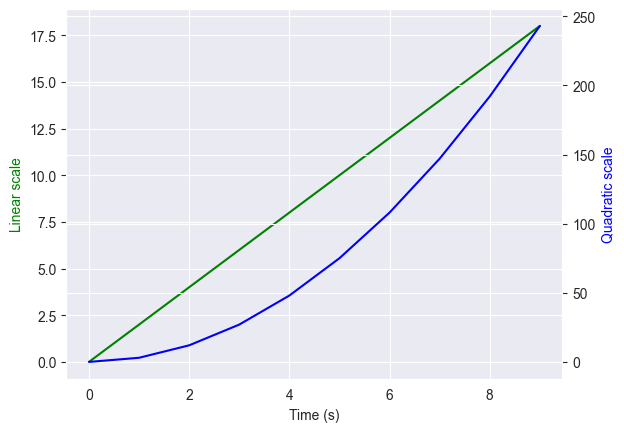

In [99]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
x = range(0, 10)
y1 = [2 * i for i in x]
y2 = [3 * i**2 for i in x]

# Plotting on the first y-axis
ax1.plot(x, y1, 'g-')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Linear scale', color='g')

# Creating a second y-axis
ax2 = ax1.twinx()
ax2.plot(x, y2, 'b-')
ax2.set_ylabel('Quadratic scale', color='b')

plt.show()

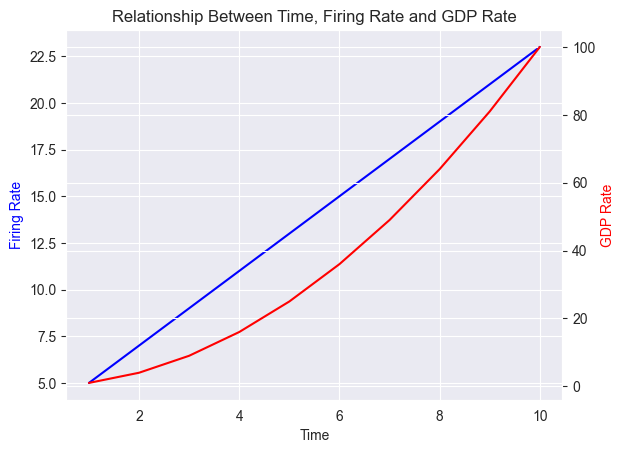

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = pd.DataFrame({
    'time': range(1, 11),
    'firing_rate': [2 * x + 3 for x in range(1, 11)],
    'gdp_rate': [x**2 for x in range(1, 11)]
})

fig, ax1 = plt.subplots()

sns.lineplot(data=data, x='time', y='firing_rate', ax=ax1, color='b')
ax1.set_ylabel('Firing Rate', color='b')

ax2 = ax1.twinx()
sns.lineplot(data=data, x='time', y='gdp_rate', ax=ax2, color='r')
ax2.set_ylabel('GDP Rate', color='r')

plt.title('Relationship Between Time, Firing Rate and GDP Rate')
ax1.set_xlabel('Time')

# Show the plot
plt.show()